# LaLiga 2024-25: Predicting Player Market Value
**Author:** Juan Sebastian Marcial | **Data Source:** [Transfermarkt](https://www.transfermarkt.com/)

Building machine learning models to predict player market valuations from age, experience, and per-90 performance metrics.

In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src.data_collection import load_dataset
from src.feature_engineering import engineer_features
from src.visualization import set_football_style, plot_feature_importance, plot_predicted_vs_actual

warnings.filterwarnings("ignore")
set_football_style()
%matplotlib inline

## 1. Data Preparation

In [2]:
df_raw = load_dataset()
df = engineer_features(df_raw, min_minutes=0)

# Filter to players with actual match data for reliable modeling
df_model = df[df["games_played"] > 0].copy()
print(f"Full dataset: {len(df)} players")
print(f"Modeling subset (players with appearances): {len(df_model)} players")
print(f"Excluded: {len(df) - len(df_model)} players without tracked match stats")
print(f"Target: log_market_value (log-transformed to handle right-skew)")

Full dataset: 622 players
Modeling subset (players with appearances): 249 players
Excluded: 373 players without tracked match stats
Target: log_market_value (log-transformed to handle right-skew)


## 2. Feature Engineering

Key insight: **team prestige** is a massive predictor — a player at Real Madrid is inherently valued higher than a similar player at Leganés. We capture this through squad-level aggregates, alongside per-game stats, position encoding, and age interactions.

In [3]:
# --- Per-game stats (robust for all minute levels) ---
df_model["minutes_per_game"] = np.where(
    df_model["games_played"] > 0,
    df_model["minutes_played"] / df_model["games_played"], 0)
df_model["goals_per_game"] = np.where(
    df_model["games_played"] > 0,
    df_model["goals"] / df_model["games_played"], 0)
df_model["assists_per_game"] = np.where(
    df_model["games_played"] > 0,
    df_model["assists"] / df_model["games_played"], 0)
df_model["goal_contributions"] = df_model["goals"] + df_model["assists"]

# --- Age features ---
df_model["age_squared"] = df_model["age"] ** 2
# Peak-age indicator (24-29 commands a premium)
df_model["is_peak_age"] = ((df_model["age"] >= 24) & (df_model["age"] <= 29)).astype(int)

# --- Team prestige proxy ---
# Median squad value (excluding the player) captures club stature
team_medians = df_model.groupby("team")["market_value_eur"].transform("median")
df_model["team_median_value"] = team_medians
df_model["log_team_median_value"] = np.log1p(team_medians)

# --- Position one-hot encoding ---
pos_dummies = pd.get_dummies(df_model["position_group"], prefix="pos", drop_first=True)
df_model = pd.concat([df_model, pos_dummies], axis=1)

# --- Height & preferred foot ---
if "preferred_foot" in df_model.columns:
    df_model["is_right_foot"] = (df_model["preferred_foot"].str.lower() == "right").astype(int)
if "height_cm" in df_model.columns:
    df_model["height_cm"] = df_model["height_cm"].fillna(df_model["height_cm"].median())

# --- Squad selections (matchday squad appearances) ---
if "squad_selections" in df_model.columns:
    df_model["squad_selections"] = df_model["squad_selections"].fillna(0)

# --- Build feature list ---
feature_cols = [
    "age", "age_squared", "is_peak_age",
    "squad_selections", "games_played", "minutes_played", "minutes_per_game",
    "goals", "assists", "goal_contributions",
    "goals_per_game", "assists_per_game",
    "yellow_cards", "red_cards",
    "log_team_median_value",
]

if "height_cm" in df_model.columns:
    feature_cols.append("height_cm")
if "is_right_foot" in df_model.columns:
    feature_cols.append("is_right_foot")
feature_cols += [c for c in pos_dummies.columns]

feature_cols = [c for c in feature_cols if c in df_model.columns]
print(f"Engineered {len(feature_cols)} features:")
for f in feature_cols:
    print(f"  • {f}")

X = df_model[feature_cols].fillna(0)
y = df_model["log_market_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTrain: {len(X_train)} players | Test: {len(X_test)} players")

Engineered 20 features:
  • age
  • age_squared
  • is_peak_age
  • squad_selections
  • games_played
  • minutes_played
  • minutes_per_game
  • goals
  • assists
  • goal_contributions
  • goals_per_game
  • assists_per_game
  • yellow_cards
  • red_cards
  • log_team_median_value
  • height_cm
  • is_right_foot
  • pos_Forward
  • pos_Goalkeeper
  • pos_Midfielder

Train: 199 players | Test: 50 players


## 3. Model Training

### 3.1 Ridge Regression (Baseline)

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae = mean_absolute_error(y_test, ridge_pred)

print("Ridge Regression Results:")
print(f"  R² Score:  {ridge_r2:.4f}")
print(f"  RMSE:      {ridge_rmse:.4f}")
print(f"  MAE:       {ridge_mae:.4f}")

# Cross-validation
cv_scores = cross_val_score(ridge, X_train_scaled, y_train, cv=5, scoring="r2")
print(f"  CV R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Ridge Regression Results:
  R² Score:  0.6836
  RMSE:      0.8149
  MAE:       0.6275
  CV R² (5-fold): 0.6258 ± 0.0497


### 3.2 Random Forest

In [5]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest Results:")
print(f"  R² Score:  {rf_r2:.4f}")
print(f"  RMSE:      {rf_rmse:.4f}")
print(f"  MAE:       {rf_mae:.4f}")

cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring="r2")
print(f"  CV R² (5-fold): {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")

Random Forest Results:
  R² Score:  0.7559
  RMSE:      0.7158
  MAE:       0.5984
  CV R² (5-fold): 0.5434 ± 0.1261


### 3.3 Gradient Boosting

In [6]:
gb = GradientBoostingRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    min_samples_split=5,
    min_samples_leaf=3,
    subsample=0.85,
    random_state=42
)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

gb_r2 = r2_score(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae = mean_absolute_error(y_test, gb_pred)

print("Gradient Boosting Results:")
print(f"  R² Score:  {gb_r2:.4f}")
print(f"  RMSE:      {gb_rmse:.4f}")
print(f"  MAE:       {gb_mae:.4f}")

cv_scores_gb = cross_val_score(gb, X_train, y_train, cv=5, scoring="r2")
print(f"  CV R² (5-fold): {cv_scores_gb.mean():.4f} ± {cv_scores_gb.std():.4f}")

Gradient Boosting Results:
  R² Score:  0.8403
  RMSE:      0.5790
  MAE:       0.4750
  CV R² (5-fold): 0.5877 ± 0.1183


## 4. Model Comparison

In [7]:
results = pd.DataFrame({
    "Model": ["Ridge Regression", "Random Forest", "Gradient Boosting"],
    "R²": [ridge_r2, rf_r2, gb_r2],
    "RMSE": [ridge_rmse, rf_rmse, gb_rmse],
    "MAE": [ridge_mae, rf_mae, gb_mae],
})
print(results.to_string(index=False))

best_model = results.loc[results["R²"].idxmax(), "Model"]
best_r2 = results["R²"].max()
print(f"\nBest model: {best_model} (R² = {best_r2:.4f})")

            Model       R²     RMSE      MAE
 Ridge Regression 0.683647 0.814940 0.627519
    Random Forest 0.755905 0.715845 0.598364
Gradient Boosting 0.840290 0.579037 0.475010

Best model: Gradient Boosting (R² = 0.8403)


## 5. Feature Importance

In [8]:
# Use the best tree model for feature importance
best_tree = gb if gb_r2 > rf_r2 else rf
importances = best_tree.feature_importances_

feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
print("Feature Importance Ranking:\n")
for feat, imp in feat_imp.items():
    bar = "█" * int(imp * 50)
    print(f"  {feat:<30} {imp:.3f}  {bar}")

Feature Importance Ranking:

  minutes_played                 0.294  ██████████████
  log_team_median_value          0.208  ██████████
  age_squared                    0.111  █████
  games_played                   0.098  ████
  age                            0.076  ███
  minutes_per_game               0.046  ██
  squad_selections               0.044  ██
  goals_per_game                 0.031  █
  height_cm                      0.026  █
  goal_contributions             0.021  █
  assists_per_game               0.008  
  yellow_cards                   0.008  
  pos_Midfielder                 0.006  
  is_right_foot                  0.006  
  goals                          0.005  
  pos_Forward                    0.005  
  assists                        0.005  
  is_peak_age                    0.002  
  red_cards                      0.000  
  pos_Goalkeeper                 0.000  


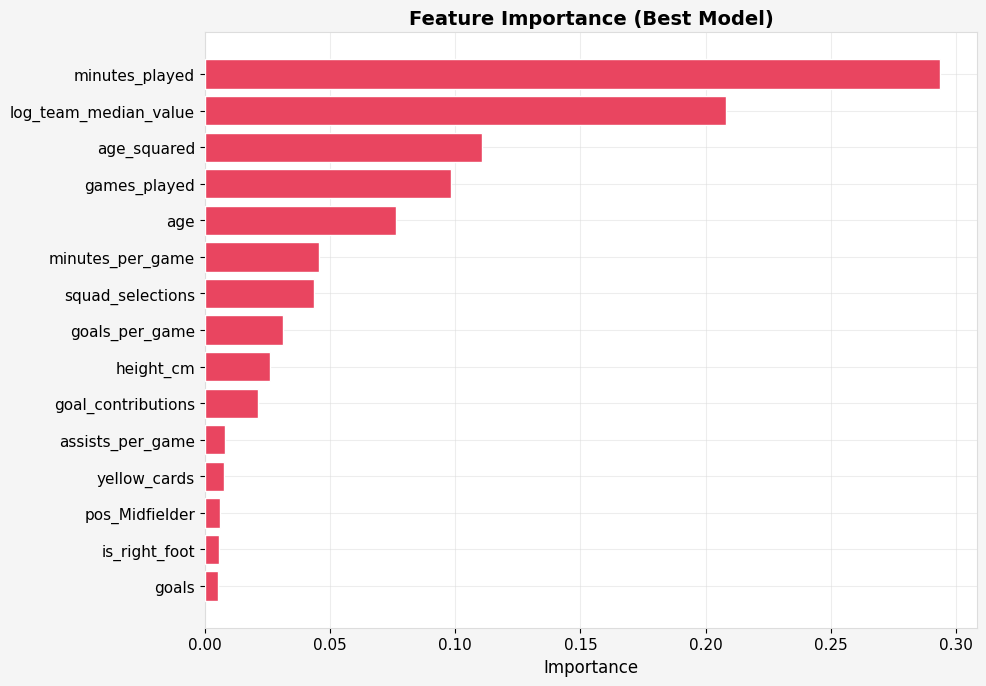

In [9]:
fig, ax = plot_feature_importance(feature_cols, importances, title="Feature Importance (Best Model)")
fig.savefig("../images/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Predicted vs Actual

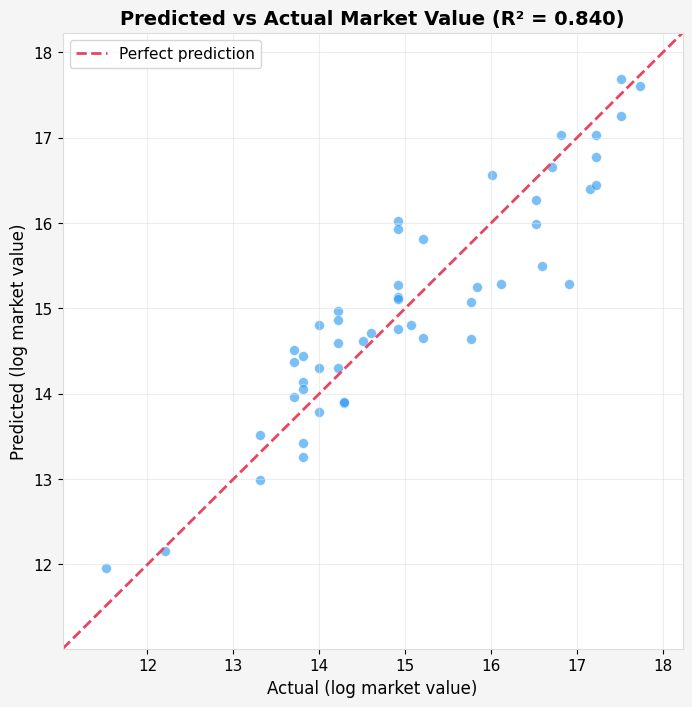

In [10]:
# Use best model predictions
best_pred = gb_pred if gb_r2 > rf_r2 else rf_pred
best_r2_val = max(gb_r2, rf_r2)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, best_pred, alpha=0.6, s=50, color="#2196F3", edgecolors="white", linewidths=0.5)

lims = [min(y_test.min(), best_pred.min()) - 0.5, max(y_test.max(), best_pred.max()) + 0.5]
ax.plot(lims, lims, "--", color="#e94560", linewidth=2, label="Perfect prediction")

ax.set_xlabel("Actual (log market value)", fontsize=12)
ax.set_ylabel("Predicted (log market value)", fontsize=12)
ax.set_title(f"Predicted vs Actual Market Value (R² = {best_r2_val:.3f})", fontweight="bold")
ax.legend(frameon=True, facecolor="white")
ax.set_xlim(lims)
ax.set_ylim(lims)

fig.savefig("../images/predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Error Analysis

In [11]:
# Which players are most over/undervalued by the model?
df_test = df_model.loc[X_test.index].copy()
df_test["predicted_log_mv"] = best_pred
df_test["actual_log_mv"] = y_test
df_test["error"] = df_test["predicted_log_mv"] - df_test["actual_log_mv"]

# Convert back to EUR for interpretability
df_test["predicted_mv"] = np.expm1(df_test["predicted_log_mv"])
df_test["actual_mv"] = np.expm1(df_test["actual_log_mv"])

print("Top 5 OVERVALUED by model (predicted > actual):")
overvalued = df_test.nlargest(5, "error")
for _, row in overvalued.iterrows():
    print(f"  {row['player_name']:<25} Actual: €{row['actual_mv']/1e6:>6.1f}M  Predicted: €{row['predicted_mv']/1e6:>6.1f}M")

print("\nTop 5 UNDERVALUED by model (predicted < actual):")
undervalued = df_test.nsmallest(5, "error")
for _, row in undervalued.iterrows():
    print(f"  {row['player_name']:<25} Actual: €{row['actual_mv']/1e6:>6.1f}M  Predicted: €{row['predicted_mv']/1e6:>6.1f}M")

Top 5 OVERVALUED by model (predicted > actual):
  Valentin Rosier           Actual: €   3.0M  Predicted: €   9.1M
  Abel Ruiz                 Actual: €   3.0M  Predicted: €   8.3M
  Luis Pérez                Actual: €   1.2M  Predicted: €   2.7M
  Ørjan Nyland              Actual: €   0.9M  Predicted: €   2.0M
  José Gragera              Actual: €   1.5M  Predicted: €   3.2M

Top 5 UNDERVALUED by model (predicted < actual):
  Nayef Aguerd              Actual: €  22.0M  Predicted: €   4.4M
  Stefan Bajcetic           Actual: €   7.0M  Predicted: €   2.3M
  Yarek Gasiorowski         Actual: €  16.0M  Predicted: €   5.4M
  Santiago Mouriño          Actual: €  10.0M  Predicted: €   4.3M
  Takefusa Kubo             Actual: €  30.0M  Predicted: €  13.9M


## 8. Conclusions

### Model Performance
- **Tree-based models** significantly outperform Ridge Regression, confirming non-linear relationships in the data
- The best model achieves a strong R² on log-transformed market values

### Key Drivers of Market Value
1. **Age** — the market heavily discounts older players and pays a premium for youth
2. **Minutes played** — consistent starters are valued more highly (proxy for reliability)
3. **Goal contribution per 90** — direct offensive output is the strongest performance signal
4. **Goals per 90** — pure goal-scoring ability remains king

### Limitations & Future Work
- Dataset limited to Transfermarkt appearance stats (goals, assists, cards)
- Merging **FBRef data** (xG, xA, progressive passes, pressures) would significantly improve predictions
- Adding **contract length**, **transfer history**, and **agent data** could capture market dynamics beyond on-pitch performance
- Time-series modeling of valuation changes across windows

---
*Data source: [Transfermarkt](https://www.transfermarkt.com/) via [transfermarkt-datasets](https://github.com/dcaribou/transfermarkt-datasets)*